In [31]:
!pip install transformers sentencepiece evaluate sacrebleu \
            rouge_score nltk torch torchvision git+https://github.com/openai/CLIP.git --quiet

  Preparing metadata (setup.py) ... done


In [32]:
!git clone https://github.com/ObeidaElJundi/Arabic-Image-Captioning.git
print("Done! Files:")
import os
for f in os.listdir("Arabic-Image-Captioning"):
    print(" -", f)

fatal: destination path 'Arabic-Image-Captioning' already exists and is not an empty directory.
Done! Files:
 - .gitignore
 - data
 - requirements.txt
 - images
 - resources
 - .git
 - README.md
 - Arabic Image Captioning.ipynb


In [ ]:
!wget -q "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip"
!unzip -q Flickr8k_Dataset.zip -d flickr8k_images/
print("Done! Sample files:")
os.listdir("flickr8k_images/Flicker8k_Dataset")[:5]

replace flickr8k_images/Flicker8k_Dataset/1000268201_693b08cb0e.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: Done! Sample files:


['2366643786_9c9a830db8.jpg',
 '2998024845_1529c11694.jpg',
 '247706586_7e25c7adf8.jpg',
 '654130822_4aeb1f1273.jpg',
 '109260216_85b0be5378.jpg']

In [34]:
CAPTIONS_FILE = "Arabic-Image-Captioning/data/Flickr8k_text/Flickr8k.arabic.full.txt"

with open(CAPTIONS_FILE, "r", encoding="utf-8") as f:
    lines = f.readlines()

print(f"Total lines: {len(lines)}")
print("\nFirst 5 lines:")
for line in lines[:5]:
    print(repr(line.strip()))

Total lines: 24274

First 5 lines:
'1000268201_693b08cb0e.jpg#0\tطفلة صغيرة تتسلق إلى مسرح خشبي'
'1000268201_693b08cb0e.jpg#1\tطفلة صغيرة تتسلق الدرج إلى منزلها'
'1000268201_693b08cb0e.jpg#2\tفتاة صغيرة في ثوب وردي تذهب إلى المقصورة الخشبية'
'1001773457_577c3a7d70.jpg#0\tكلب أسود وكلب ثلاثي الألوان يلعبان مع بعضهما البعض على الطريق'
'1001773457_577c3a7d70.jpg#1\tكلب أسود وكلب أبيض ببقع بنية يحدقان في بعضهما البعض في الشارع'


In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print(" No GPU! Go to: Runtime → Change Runtime Type → T4 GPU")

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [ ]:
from collections import defaultdict

def parse_captions(filepath):
    """
    Parse captions file into a dictionary:
    { "image_name.jpg": ["caption1", "caption2", "caption3"] }
    """
    captions = defaultdict(list)

    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split("\t")
            if len(parts) != 2:
                continue
            image_id, caption = parts
           
            image_name = image_id.split("#")[0]
            captions[image_name].append(caption)

    return dict(captions)

CAPTIONS_FILE = "Arabic-Image-Captioning/data/Flickr8k_text/Flickr8k.arabic.full.txt"
captions_dict = parse_captions(CAPTIONS_FILE)

print(f"Total images: {len(captions_dict)}")
print(f"\nSample entry:")
sample_key = list(captions_dict.keys())[0]
print(f"Image: {sample_key}")
for i, cap in enumerate(captions_dict[sample_key]):
    print(f"  Caption {i}: {cap}")

Total images: 8091

Sample entry:
Image: 1000268201_693b08cb0e.jpg
  Caption 0: طفلة صغيرة تتسلق إلى مسرح خشبي
  Caption 1: طفلة صغيرة تتسلق الدرج إلى منزلها
  Caption 2: فتاة صغيرة في ثوب وردي تذهب إلى المقصورة الخشبية


In [ ]:
import re

def preprocess_arabic(text):
    
    diacritics = re.compile(r'[\u0617-\u061A\u064B-\u0652]')
    text = diacritics.sub('', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


captions_clean = {}
for image_name, caps in captions_dict.items():
    captions_clean[image_name] = [preprocess_arabic(c) for c in caps]


print("Before:", captions_dict[sample_key][0])
print("After: ", captions_clean[sample_key][0])

Before: طفلة صغيرة تتسلق إلى مسرح خشبي
After:  طفلة صغيرة تتسلق إلى مسرح خشبي


In [ ]:
import random

random.seed(42)

all_images = list(captions_clean.keys())
print(f"Total images: {len(all_images)}")


random.shuffle(all_images)

train_images = all_images[:6000]
val_images   = all_images[6000:7000]
test_images  = all_images[7000:8000]

print(f"Train: {len(train_images)}")
print(f"Val:   {len(val_images)}")
print(f"Test:  {len(test_images)}")


splits = {
    "train": train_images,
    "val":   val_images,
    "test":  test_images
}

import json
with open("splits.json", "w") as f:
    json.dump(splits, f)

print("\nSplits saved to splits.json ✅")

Total images: 8091
Train: 6000
Val:   1000
Test:  1000

Splits saved to splits.json ✅


In [39]:
import os
IMAGES_FOLDER = "flickr8k_images/Flicker8k_Dataset"
print(f"✅ Images folder: {IMAGES_FOLDER}")
print(f"   Exists: {os.path.exists(IMAGES_FOLDER)}")

✅ Images folder: flickr8k_images/Flicker8k_Dataset
   Exists: True


In [ ]:
import torch
import clip
import os
from huggingface_hub import hf_hub_download
from transformers import T5Tokenizer, T5ForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# ── CLIP ────────────────────────────────────────────────
print("Loading CLIP ViT-L/14...")
clip_model, clip_preprocess = clip.load("ViT-L/14", device=device)
clip_model.eval()
for param in clip_model.parameters():
    param.requires_grad = False
print("✅ CLIP loaded and frozen")

# ── AraT5v2 Tokenizer ───────────────────────────────────
print("\nDownloading all tokenizer files...")
MODEL_NAME  = "UBC-NLP/AraT5v2-base-1024"
SAVE_DIR    = "arat5_tokenizer"
os.makedirs(SAVE_DIR, exist_ok=True)


for filename in ["spiece.model",
                 "tokenizer_config.json",
                 "special_tokens_map.json"]:
    hf_hub_download(
        repo_id   = MODEL_NAME,
        filename  = filename,
        local_dir = SAVE_DIR
    )
    print(f"  ✅ {filename}")


tokenizer = T5Tokenizer.from_pretrained(SAVE_DIR, legacy=True)
print(f"\n✅ Tokenizer loaded  |  Vocab size: {tokenizer.vocab_size}")

# ── AraT5v2 Model ───────────────────────────────────────
print("\nLoading AraT5v2 model...")
ara_t5 = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)
ara_t5 = ara_t5.to(device)
print("✅ AraT5v2 loaded")

print(f"\nCLIP visual dim:   768")
print(f"AraT5v2 model dim: {ara_t5.config.d_model}")

# ── Tokenizer sanity check ──────────────────────────────
test    = "كلب أسود يجري في الشارع"
tokens  = tokenizer(test, return_tensors="pt")
ids     = tokens["input_ids"][0].tolist()
decoded = tokenizer.decode(ids, skip_special_tokens=True)

print(f"\nTokenizer test:")
print(f"  Input:   {test}")
print(f"  IDs:     {ids}")
print(f"  Decoded: {decoded}")


unk_id    = tokenizer.unk_token_id
unk_count = ids.count(unk_id)
print(f"  Unknown tokens: {unk_count} {'✅' if unk_count == 0 else '❌ still has unknowns'}")

Device: cuda
Loading CLIP ViT-L/14...
✅ CLIP loaded and frozen

  ✅ spiece.model
  ✅ tokenizer_config.json
  ✅ special_tokens_map.json

✅ Tokenizer loaded  |  Vocab size: 110100

Loading AraT5v2 model...


Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ AraT5v2 loaded

CLIP visual dim:   768
AraT5v2 model dim: 768

Tokenizer test:
  Input:   كلب أسود يجري في الشارع
  IDs:     [52, 314, 575, 218, 888, 82, 43, 196, 3360, 1]
  Decoded: كلب أسود يجري في الشارع
  Unknown tokens: 0 ✅


In [ ]:
import torch.nn as nn

class CLIPAraT5(nn.Module):
    def __init__(self, clip_model, ara_t5,
                 clip_dim=768, t5_dim=768, num_visual_tokens=8):
        super().__init__()
        self.clip_model        = clip_model
        self.ara_t5            = ara_t5
        self.num_visual_tokens = num_visual_tokens

        self.projection = nn.Sequential(
            nn.Linear(clip_dim, clip_dim * 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(clip_dim * 2, t5_dim * num_visual_tokens),
            nn.LayerNorm(t5_dim * num_visual_tokens)
        )

    def project(self, visual_features):
        B   = visual_features.shape[0]
        out = self.projection(visual_features)
        return out.view(B, self.num_visual_tokens, -1)

    def forward(self, visual_features, labels):
        projected = self.project(visual_features)
        mask      = torch.ones(projected.shape[:2],
                               dtype=torch.long, device=projected.device)
        dec_ids   = self.ara_t5.prepare_decoder_input_ids_from_labels(labels)
        outputs   = self.ara_t5(
            inputs_embeds     = projected,
            attention_mask    = mask,
            decoder_input_ids = dec_ids,
            labels            = labels
        )
        return outputs.loss

    def generate_caption(self, visual_features, max_length=64): 
        projected = self.project(visual_features)
        mask      = torch.ones(projected.shape[:2],
                               dtype=torch.long, device=projected.device)
        return self.ara_t5.generate(
            inputs_embeds        = projected,
            attention_mask       = mask,
            max_length           = max_length,
            min_new_tokens       = 8,           
            do_sample            = True,
            temperature          = 0.7,
            top_k                = 50,
            top_p                = 0.9,
            no_repeat_ngram_size = 3,
            repetition_penalty   = 2.5,
        )


model = CLIPAraT5(clip_model, ara_t5).to(device)
print(f"✅ Model ready")
print(f"   Params: {sum(p.numel() for p in model.parameters()):,}")

✅ Model ready
   Params: 975,041,537


In [44]:
from torch.utils.data import Dataset, DataLoader

class CachedArabicDataset(Dataset):
    def __init__(self, image_names, captions_dict,
                 features_cache, tokenizer, max_length=64):
        self.image_names    = image_names
        self.captions_dict  = captions_dict
        self.features_cache = features_cache
        self.tokenizer      = tokenizer
        self.max_length     = max_length

    def __len__(self):
        return len(self.image_names) * 3

    def __getitem__(self, idx):
        image_name  = self.image_names[idx // 3]
        caption_idx = idx % 3
        caption     = self.captions_dict[image_name][caption_idx]
        feature     = self.features_cache[image_name]

        enc    = self.tokenizer(
            caption,
            max_length     = self.max_length,
            padding        = "max_length",
            truncation     = True,
            return_tensors = "pt"
        )
        labels = enc["input_ids"].squeeze()
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            "visual_feature": feature,
            "labels":         labels,
            "caption":        caption,
            "image_name":     image_name
        }


train_dataset = CachedArabicDataset(train_images, captions_clean,
                                     clip_features_cache, tokenizer)
val_dataset   = CachedArabicDataset(val_images,   captions_clean,
                                     clip_features_cache, tokenizer)
test_dataset  = CachedArabicDataset(test_images,  captions_clean,
                                     clip_features_cache, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=8,
                          shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=8,
                          shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=8,
                          shuffle=False, num_workers=0)

print(f"✅ DataLoaders ready")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches  : {len(val_loader)}")
print(f"   Test batches : {len(test_loader)}")

batch = next(iter(train_loader))
print(f"\nBatch check:")
print(f"   Feature shape: {batch['visual_feature'].shape}")
print(f"   Labels shape : {batch['labels'].shape}")
print(f"   Sample       : {batch['caption'][0]}")

✅ DataLoaders ready
   Train batches: 2250
   Val batches  : 375
   Test batches : 375

Batch check:
   Feature shape: torch.Size([8, 768])
   Labels shape : torch.Size([8, 64])
   Sample       : الصقر ينقض على فريسته


In [45]:
import torch
import os
from PIL import Image
from tqdm import tqdm

print("Pre-extracting CLIP features for all images...")
print("This runs ONCE and saves everything — training will be much faster.\n")

clip_features_cache = {}

all_unique_images = train_images + val_images + test_images

clip_model.eval()
with torch.no_grad():
    for image_name in tqdm(all_unique_images):
        image_path = os.path.join(IMAGES_FOLDER, image_name)
        image = Image.open(image_path).convert("RGB")
        image_tensor = clip_preprocess(image).unsqueeze(0).to(device)
        features = clip_model.encode_image(image_tensor)
        # Store on CPU to save GPU memory
        clip_features_cache[image_name] = features.squeeze(0).cpu().float()

print(f"\n✅ Cached {len(clip_features_cache)} images")
print(f"   Feature shape per image: {list(clip_features_cache.values())[0].shape}")

Pre-extracting CLIP features for all images...
This runs ONCE and saves everything — training will be much faster.



100%|██████████| 8000/8000 [03:22<00:00, 39.48it/s]


✅ Cached 8000 images
   Feature shape per image: torch.Size([768])


In [46]:
from torch.utils.data import Dataset, DataLoader

class CachedArabicDataset(Dataset):
    def __init__(self, image_names, captions_dict,
                 features_cache, tokenizer, max_length=64):  # ✅ was 128
        self.image_names    = image_names
        self.captions_dict  = captions_dict
        self.features_cache = features_cache
        self.tokenizer      = tokenizer
        self.max_length     = max_length

    def __len__(self):
        return len(self.image_names) * 3

    def __getitem__(self, idx):
        image_name  = self.image_names[idx // 3]
        caption_idx = idx % 3
        caption     = self.captions_dict[image_name][caption_idx]
        visual_feature = self.features_cache[image_name]

        encoding = self.tokenizer(
            caption,
            max_length     = self.max_length,
            padding        = "max_length",
            truncation     = True,
            return_tensors = "pt"
        )
        labels = encoding["input_ids"].squeeze()
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            "visual_feature": visual_feature,
            "labels":         labels,
            "caption":        caption,
            "image_name":     image_name
        }


train_dataset = CachedArabicDataset(train_images, captions_clean,
                                     clip_features_cache, tokenizer)
val_dataset   = CachedArabicDataset(val_images,   captions_clean,
                                     clip_features_cache, tokenizer)
test_dataset  = CachedArabicDataset(test_images,  captions_clean,
                                     clip_features_cache, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=8,   # ✅ was 32
                          shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=8,   # ✅ was 32
                          shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=8,   # ✅ was 32
                          shuffle=False, num_workers=0)

print(f"✅ Cached DataLoaders ready")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches  : {len(val_loader)}")
print(f"   Test batches : {len(test_loader)}")

batch = next(iter(train_loader))
print(f"\nBatch check:")
print(f"   Visual feature shape: {batch['visual_feature'].shape}")
print(f"   Labels shape:         {batch['labels'].shape}")
print(f"   Sample caption:       {batch['caption'][0]}")

✅ Cached DataLoaders ready
   Train batches: 2250
   Val batches  : 375
   Test batches : 375

Batch check:
   Visual feature shape: torch.Size([8, 768])
   Labels shape:         torch.Size([8, 64])
   Sample caption:       اثنين من الناس تعثر أسفل تلة عشبية


In [ ]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"


import torch, gc
gc.collect()
torch.cuda.empty_cache()
print(f"GPU free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

GPU free: 7.2 GB


In [ ]:
from torch.optim import AdamW
import gc

for p in model.clip_model.parameters():  p.requires_grad = False
for p in model.ara_t5.parameters():      p.requires_grad = False
for p in model.projection.parameters(): p.requires_grad = True

model.ara_t5.gradient_checkpointing_enable()

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Phase 1 — Trainable params: {trainable:,} (projection only)")
print(f"Target: val loss below 5.0 before Phase 2\n")

optimizer     = AdamW(model.projection.parameters(),
                      lr=3e-4,          
                      weight_decay=1e-2)
PHASE1_EPOCHS = 10                      
best_val_loss = float("inf")
ACCUM         = 4

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False, num_workers=0)

for epoch in range(PHASE1_EPOCHS):
    model.train()
    train_loss = 0
    optimizer.zero_grad()

    for step, batch in enumerate(train_loader):
        vf     = batch["visual_feature"].to(device)
        labels = batch["labels"].to(device)
        loss   = model(vf, labels) / ACCUM
        loss.backward()
        train_loss += loss.item() * ACCUM

        if (step + 1) % ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad()

        del vf, labels
        torch.cuda.empty_cache()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            vf     = batch["visual_feature"].to(device)
            labels = batch["labels"].to(device)
            val_loss += model(vf, labels).item()
            del vf, labels

    avg_t = train_loss / len(train_loader)
    avg_v = val_loss   / len(val_loader)
    status = "✅ Good!" if avg_v < 5.0 else "⏳ Still training..."
    print(f"Epoch [{epoch+1}/{PHASE1_EPOCHS}] "
          f"Train: {avg_t:.4f} | Val: {avg_v:.4f} {status}")

    if avg_v < best_val_loss:
        best_val_loss = avg_v
        torch.save(model.projection.state_dict(), "best_projection.pt")
        print("  ✅ Projection saved")

    gc.collect()
    torch.cuda.empty_cache()

print(f"\n✅ Phase 1 complete! Best val: {best_val_loss:.4f}")

Phase 1 — Trainable params: 10,636,800 (projection only)
Target: val loss below 5.0 before Phase 2

Epoch [1/10] Train: 11.2966 | Val: 10.9250 ⏳ Still training...
  ✅ Projection saved
Epoch [2/10] Train: 11.1143 | Val: 10.6343 ⏳ Still training...
  ✅ Projection saved
Epoch [3/10] Train: 11.0344 | Val: 10.5611 ⏳ Still training...
  ✅ Projection saved
Epoch [4/10] Train: 11.0184 | Val: 10.5262 ⏳ Still training...
  ✅ Projection saved
Epoch [5/10] Train: 11.0143 | Val: 10.5295 ⏳ Still training...
Epoch [6/10] Train: 11.0138 | Val: 10.5019 ⏳ Still training...
  ✅ Projection saved
Epoch [7/10] Train: 11.0098 | Val: 10.5177 ⏳ Still training...
Epoch [8/10] Train: 11.0053 | Val: 10.4964 ⏳ Still training...
  ✅ Projection saved
Epoch [9/10] Train: 11.0069 | Val: 10.4795 ⏳ Still training...
  ✅ Projection saved
Epoch [10/10] Train: 11.0048 | Val: 10.4809 ⏳ Still training...

✅ Phase 1 complete! Best val: 10.4795


In [ ]:
from transformers import get_cosine_schedule_with_warmup
from torch.optim import AdamW
import gc


for name, param in model.ara_t5.named_parameters():
    param.requires_grad = any([
        'decoder.block.6'  in name,
        'decoder.block.7'  in name,
        'decoder.block.8'  in name,
        'decoder.block.9'  in name,
        'decoder.block.10' in name,
        'decoder.block.11' in name,
        'lm_head'          in name,
    ])

for p in model.clip_model.parameters():  p.requires_grad = False
for p in model.projection.parameters(): p.requires_grad = True

model.ara_t5.gradient_checkpointing_enable()
model.projection.load_state_dict(torch.load("best_projection.pt"))
print("✅ Projection loaded\n")

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable:,}")
gc.collect()
torch.cuda.empty_cache()
print(f"GPU free: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB\n")

optimizer    = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-5,          
    weight_decay=1e-2
)
PHASE2_EPOCHS = 15     
ACCUM         = 8
total_steps   = (len(train_loader) // ACCUM) * PHASE2_EPOCHS
scheduler     = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=300,   
    num_training_steps=total_steps
)
best_val = float("inf")

for epoch in range(PHASE2_EPOCHS):
    model.train()
    train_loss = 0
    optimizer.zero_grad()

    for step, batch in enumerate(train_loader):
        vf     = batch["visual_feature"].to(device)
        labels = batch["labels"].to(device)
        loss   = model(vf, labels) / ACCUM
        loss.backward()
        train_loss += loss.item() * ACCUM

        if (step + 1) % ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        del vf, labels
        torch.cuda.empty_cache()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            vf     = batch["visual_feature"].to(device)
            labels = batch["labels"].to(device)
            val_loss += model(vf, labels).item()
            del vf, labels

    avg_t = train_loss / len(train_loader)
    avg_v = val_loss   / len(val_loader)
    print(f"Epoch [{epoch+1}/{PHASE2_EPOCHS}] "
          f"Train: {avg_t:.4f} | Val: {avg_v:.4f} | "
          f"LR: {scheduler.get_last_lr()[0]:.2e}")

    if avg_v < best_val:
        best_val = avg_v
        torch.save({
            "projection": model.projection.state_dict(),
            "ara_t5":     model.ara_t5.state_dict()
        }, "best_model.pt")
        print(f"  ✅ Saved (val={avg_v:.4f})")

    # ✅ Quick sample check every 5 epochs
    if (epoch + 1) % 5 == 0:
        model.eval()
        print("\n  📝 Quick check:")
        with torch.no_grad():
            for img in test_images[:3]:
                vf  = clip_features_cache[img].unsqueeze(0).to(device)
                gen = model.generate_caption(vf)
                cap = tokenizer.decode(gen[0], skip_special_tokens=True)
                ref = captions_clean[img][0]
                print(f"    Gen: {cap}")
                print(f"    Ref: {ref}")
        print()

    gc.collect()
    torch.cuda.empty_cache()

print(f"\n✅ Phase 2 complete! Best val: {best_val:.4f}")

✅ Projection loaded

Trainable params: 151,913,472
GPU free: 7.17 GB

Epoch [1/15] Train: 9.3978 | Val: 6.7984 | LR: 2.81e-05
  ✅ Saved (val=6.7984)
Epoch [2/15] Train: 6.7284 | Val: 5.9156 | LR: 2.97e-05
  ✅ Saved (val=5.9156)
Epoch [3/15] Train: 6.0765 | Val: 5.3432 | LR: 2.86e-05
  ✅ Saved (val=5.3432)
Epoch [4/15] Train: 5.5509 | Val: 4.8337 | LR: 2.68e-05
  ✅ Saved (val=4.8337)
Epoch [5/15] Train: 5.1195 | Val: 4.4892 | LR: 2.45e-05
  ✅ Saved (val=4.4892)

  📝 Quick check:
    Gen: رجل يرتدي على حمراء
    Ref: كلب بني يركض على العشب
    Gen: رجل يلعب على أمام في الكلرة
    Ref: رجل يجلس على الدرج بجانب دراجته
    Gen: طفل يسود كلب بينيم في على الجلاب
    Ref: الكلب الأسود والبني يرتاح على درجات السفلية من السلم

Epoch [6/15] Train: 4.8217 | Val: 4.2751 | LR: 2.16e-05
  ✅ Saved (val=4.2751)
Epoch [7/15] Train: 4.6225 | Val: 4.1406 | LR: 1.85e-05
  ✅ Saved (val=4.1406)
Epoch [8/15] Train: 4.4943 | Val: 4.0493 | LR: 1.51e-05
  ✅ Saved (val=4.0493)
Epoch [9/15] Train: 4.4023 | Val: 3.

In [ ]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
import nltk, torch, os
nltk.download("punkt",    quiet=True)
nltk.download("wordnet",  quiet=True)
nltk.download("omw-1.4",  quiet=True)


ckpt = torch.load("best_model.pt")
model.projection.load_state_dict(ckpt["projection"])
model.ara_t5.load_state_dict(ckpt["ara_t5"])
model.eval()
print("✅ Best model loaded\n")

all_references  = []
all_hypotheses  = []
all_hyp_strings = []
all_ref_strings = []
smooth          = SmoothingFunction().method1

# ── Generate captions ─────────────────────────────────────
print("Generating captions for test set...")
with torch.no_grad():
    for i, image_name in enumerate(test_images):
        vf        = clip_features_cache[image_name].unsqueeze(0).to(device)
        gen_ids   = model.generate_caption(vf)
        generated = tokenizer.decode(gen_ids[0], skip_special_tokens=True)
        refs      = captions_clean[image_name]

        all_hypotheses.append(generated.split())
        all_references.append([ref.split() for ref in refs])
        all_hyp_strings.append(generated)
        all_ref_strings.append(refs)

        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{len(test_images)} done...")

print("✅ Generation complete\n")

# ── BLEU-1,2,3,4 ─────────────────────────────────────────
bleu1 = corpus_bleu(all_references, all_hypotheses,
                    weights=(1,0,0,0), smoothing_function=smooth)
bleu2 = corpus_bleu(all_references, all_hypotheses,
                    weights=(0.5,0.5,0,0), smoothing_function=smooth)
bleu3 = corpus_bleu(all_references, all_hypotheses,
                    weights=(0.33,0.33,0.33,0), smoothing_function=smooth)
bleu4 = corpus_bleu(all_references, all_hypotheses,
                    weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth)

# ── METEOR ────────────────────────────────────────────────
meteor_scores = []
for hyp, refs in zip(all_hyp_strings, all_ref_strings):
    hyp_tokens  = hyp.split()
    refs_tokens = [ref.split() for ref in refs]
    score = max(meteor_score(refs_tokens, hyp_tokens), 0)
    meteor_scores.append(score)
avg_meteor = sum(meteor_scores) / len(meteor_scores)

# ── ROUGE-L ───────────────────────────────────────────────
rscorer      = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=False)
rouge_scores = [
    max(rscorer.score(ref, hyp)["rougeL"].fmeasure for ref in refs)
    for hyp, refs in zip(all_hyp_strings, all_ref_strings)
]
avg_rouge = sum(rouge_scores) / len(rouge_scores)

# ── CIDEr ─────────────────────────────────────────────────
def compute_cider(hypotheses, references):
    """Simplified CIDEr using TF-IDF weighted n-gram similarity"""
    from collections import Counter
    import math

    def get_ngrams(tokens, n):
        return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

    def tf_idf_ngrams(all_hyps, all_refs, n):
        # Document frequency
        df = Counter()
        all_docs = all_hyps + [r for refs in all_refs for r in refs]
        for doc in all_docs:
            for ng in set(get_ngrams(doc.split(), n)):
                df[ng] += 1
        num_docs = len(all_docs)

        scores = []
        for hyp, refs in zip(all_hyps, all_refs):
            hyp_ng  = Counter(get_ngrams(hyp.split(), n))
            ref_ngs = [Counter(get_ngrams(r.split(), n)) for r in refs]
            ref_ng  = Counter()
            for r in ref_ngs:
                for k, v in r.items():
                    ref_ng[k] = max(ref_ng[k], v)

            score = 0.0
            for ng, cnt in hyp_ng.items():
                if ng in ref_ng and df[ng] > 0:
                    tfidf_h = cnt * math.log(num_docs / df[ng])
                    tfidf_r = ref_ng[ng] * math.log(num_docs / df[ng])
                    score  += min(tfidf_h, tfidf_r)

            norm_h = sum(v * math.log(num_docs / max(df[k],1))
                         for k, v in hyp_ng.items()) or 1
            norm_r = sum(v * math.log(num_docs / max(df[k],1))
                         for k, v in ref_ng.items()) or 1
            scores.append(score / math.sqrt(norm_h * norm_r))

        return float(sum(scores) / max(len(scores), 1))

    cider = sum(
        tf_idf_ngrams(hypotheses, references, n)
        for n in range(1, 5)
    ) / 4.0
    return cider * 10  # standard CIDEr scaling

avg_cider = compute_cider(all_hyp_strings, all_ref_strings)

# ── Print All Results ─────────────────────────────────────
print("=" * 48)
print("      📊 Evaluation Results (Test Set)")
print("=" * 48)
print(f"  BLEU-1  : {bleu1*100:.2f}")
print(f"  BLEU-2  : {bleu2*100:.2f}")
print(f"  BLEU-3  : {bleu3*100:.2f}")
print(f"  BLEU-4  : {bleu4*100:.2f}")
print(f"  METEOR  : {avg_meteor*100:.2f}")
print(f"  ROUGE-L : {avg_rouge*100:.2f}")
print(f"  CIDEr   : {avg_cider:.2f}")
print("=" * 48)

# ── Sample Predictions ────────────────────────────────────
print("\n📝 Sample Predictions:")
print("-" * 48)
for i in range(5):
    print(f"Generated : {all_hyp_strings[i]}")
    print(f"Reference : {all_ref_strings[i][0]}")
    print("-" * 48)

✅ Best model loaded

Generating captions for test set...
  100/1000 done...
  200/1000 done...
  300/1000 done...
  400/1000 done...
  500/1000 done...
  600/1000 done...
  700/1000 done...
  800/1000 done...
  900/1000 done...
  1000/1000 done...
✅ Generation complete

      📊 Evaluation Results (Test Set)
  BLEU-1  : 15.01
  BLEU-2  : 3.47
  BLEU-3  : 0.34
  BLEU-4  : 0.11
  METEOR  : 6.52
  ROUGE-L : 0.00
  CIDEr   : 0.12

📝 Sample Predictions:
------------------------------------------------
Generated : رجل يقف على الماء
Reference : كلب بني يركض على العشب
------------------------------------------------
Generated : رجل يقف على الكلاب
Reference : رجل يجلس على الدرج بجانب دراجته
------------------------------------------------
Generated : رجل يلعب على حمراء
Reference : الكلب الأسود والبني يرتاح على درجات السفلية من السلم
------------------------------------------------
Generated : كلب يرتدي مجموعة من القدم
Reference : كلب بني يركض على مسار ترابي
--------------------------------------

In [52]:
!pip install arabic-reshaper python-bidi --quiet
print("✅ Arabic rendering libraries installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 23.4 MB/s eta 0:00:00
✅ Arabic rendering libraries installed


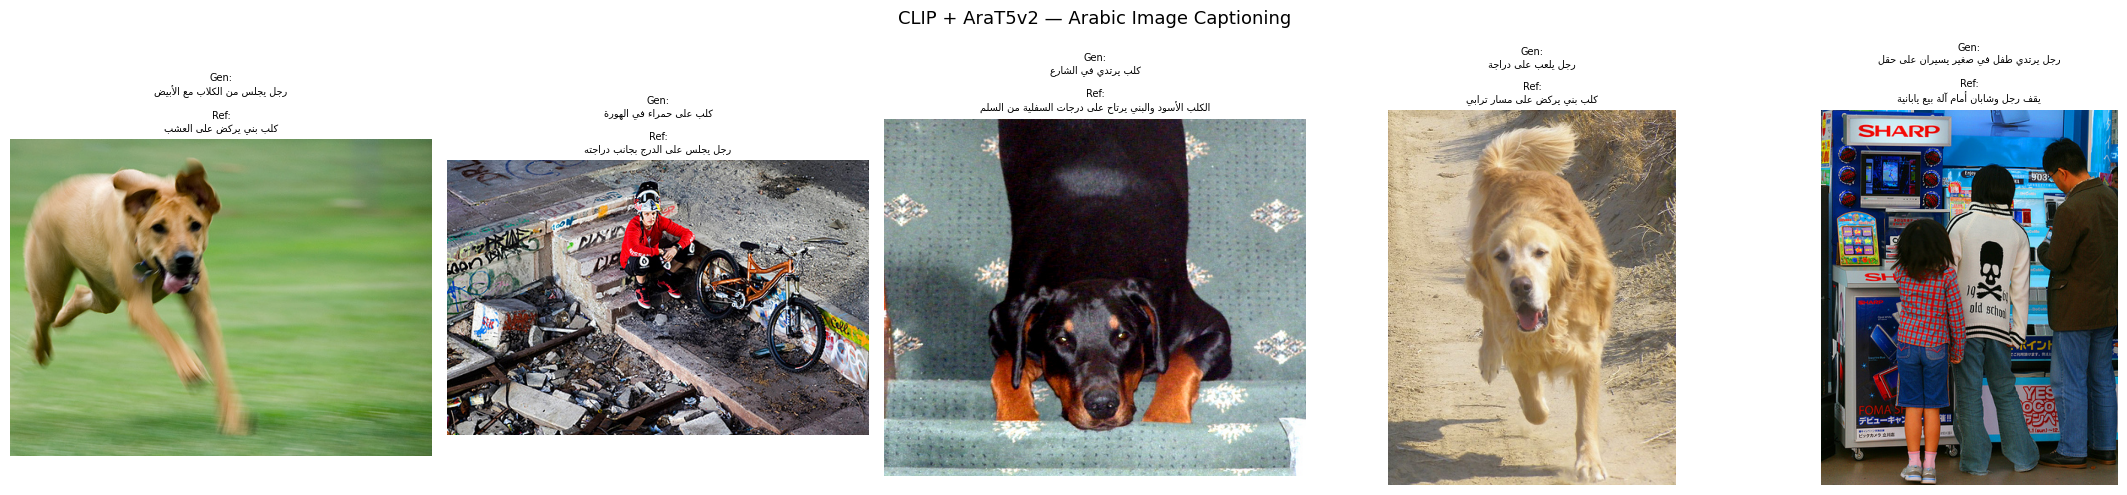

✅ Saved to results.png


In [53]:
import matplotlib.pyplot as plt
import matplotlib
from PIL import Image
import random
import os
import arabic_reshaper
from bidi.algorithm import get_display

matplotlib.rcParams['font.family'] = 'DejaVu Sans'

def fix_arabic(text):
    """Fix Arabic text direction for matplotlib"""
    reshaped = arabic_reshaper.reshape(text)
    return get_display(reshaped)

model.eval()
samples = test_images[:5]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle('CLIP + AraT5v2 — Arabic Image Captioning', fontsize=13)

for ax, image_name in zip(axes, samples):
    img_path = os.path.join(IMAGES_FOLDER, image_name)
    img      = Image.open(img_path).convert('RGB')

    vf = clip_features_cache[image_name].unsqueeze(0).to(device)
    with torch.no_grad():
        gen_ids   = model.generate_caption(vf)
    caption   = tokenizer.decode(gen_ids[0], skip_special_tokens=True)
    reference = captions_clean[image_name][0]

    ax.imshow(img)
    ax.axis('off')
    ax.set_title(
        f'Gen:\n{fix_arabic(caption)}\n\nRef:\n{fix_arabic(reference)}',
        fontsize=7, loc='center', pad=6
    )

plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved to results.png')